## FRESEAN using SVD 
**Author:** Anjali Krishna, University of Delaware, 2026.

**AI use disclosure:** Claude (Anthropic) Opus models 4.6 and 4.7 were used to help clean up portions of this script. 
All AI-assisted code has been read, annotated manually, checked, and vetted by the author, and outputs were verified against known results before use.

### Change guide: original notes preserved; additions marked

**All original Markdown notes and code comments are retained verbatim.** Corrections are placed in separate added explanations or clearly labeled comments. Original notes can therefore contain statements from the earlier implementation; the added corrections identify the current calculation.

The cell numbers below count every cell from the top, including text cells. They are not the `In [ ]` execution numbers.

| Where to look | Cells in this copy | What was added or corrected |
| --- | --- | --- |
| [ADDED CORRECTION: real/complex formulation](#change-pass-b) | 31 | A separate explanation of real spatial modes using both `F.real` and `F.imag`. The original PASS B notes remain verbatim in cell 32. |
| [ADDED: executable SVD step](#change-svd-code) | 33–34 | Explanation, the missing `passB_write_modes()` function, and its call. The function forms the Gram matrix, uses `eigh`, recovers modes, checks orthogonality, and saves results. |
| [ADDED: Kinetic-energy check](#change-ke-check) | 42–43 | Explanation and `kinetic_energy_check()`, using the original mass-weighted velocities projected onto fixed real modes. |
| [ADDED: comparisons, plot, and interpretation](#change-ke-run) | 44–47 | Runs the test, compares mode energies with original Cartesian and whole-molecule COM components, saves tables, and plots the comparison. |
| [ADDED: spectral-normalization note](#change-normalization-note) | 27 | Flags the existing VDoS plotting scale. This scale is not used by the kinetic-energy check. |

**Other corrections:** cells 15 and 19 contain separate comments explaining the corrected rank bounds while retaining the original comments. Cell 19 also reports those bounds and checks for an empty block set. Cell 39 defines `vdos_plot` when smoothing is disabled. Cell 41 fixes the undefined saved VDoS name. The original input note is also retained as written; the actual tutorial system has **22 atoms and 66 Cartesian velocity components**, not 66 amino acids.

**Real/complex correction:** Fourier coefficients remain complex at ordinary bins. Both real and imaginary parts are used to find real spatial modes. The rank ceiling is `min(nDOF, 2*nBlocks)` at ordinary bins and `min(nDOF, nBlocks)` at zero frequency and the even-N Nyquist endpoint. 

**Execution:** the corrected calculations were run on the original tutorial TRR, and their saved outputs are included. The present changes preserve those executable calculations and outputs while restoring every original note and adding labels. Place this notebook beside `align.py`, `unwrap.py`, and `ctypes/`, then use **Restart Kernel and Run All** to reproduce the calculation.

**Cached FFTs:** PASS A retains its original `overwrite=False` setting. If the input trajectory, selection, alignment reference, basin, block length, or window changes, set its call to `overwrite=True` before running PASS B. Matching shapes alone do not establish that cached data belong to the current settings.


In [1]:
import urllib.request
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import rmsd

# Custom modules from the FRESEAN tutorial repo
import unwrap as pbc
import align as fit
import sys
import os

# drop any already-loaded wrong modules so the re-import takes the local files
for m in ("unwrap", "align", "graphics"):
    sys.modules.pop(m, None)

/home/akris/.local/lib/python3.9/site-packages/MDAnalysis/analysis/data/filenames.py:110: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_filename


## Input Files

This notebook has been tested here on the 66-aa long Ala dipeptide.

In [2]:
# Input files
DATA_DIR = "data/MD-water-300K"
TOP = os.path.join(DATA_DIR, "topol.tpr")
TRR = os.path.join(DATA_DIR, "traj.trr")

TOP_URL = "https://www.dropbox.com/scl/fi/aydgkxfbtbeif7j7ptr5o/topol.tpr?rlkey=g4bztzt95dt402spumdxmz66n&dl=1"
TRR_URL = "https://www.dropbox.com/scl/fi/m0dlzyeaijw48wj8gky18/traj.trr?rlkey=gggwkd2e9rfwv8or13qgo3ulq&dl=1"

#Output directories
OUTDIR = "fresean_svd_ala_out"
FFT_DIR = os.path.join(OUTDIR, "block_ffts")
MODES_DIR = os.path.join(OUTDIR, "modes_by_bin")
PLOTS_DIR = os.path.join(OUTDIR, "plots")

SEL_STR = "all"
dt_ps = 0.004   # toy traj saved every 0.004 ps

# use only a single-conformation segment selected by phi/psi
USE_CONFORMATION_SEGMENT = True

# If selection segment is too short, set this False OR reduce N.

## Download inputs + load Universe

In [3]:
def download_if_needed(filename, url):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    if not os.path.exists(filename):
        print(f"{filename} not found. Downloading from {url} ...")
        urllib.request.urlretrieve(url, filename)
        print(f"Downloaded {filename}.")

download_if_needed(TOP, TOP_URL)
download_if_needed(TRR, TRR_URL)

u = mda.Universe(TOP, TRR)
sel = u.select_atoms(SEL_STR)

print("nAtoms =", sel.n_atoms)                    # number of atoms selected
print("nDOF    =", 3 * sel.n_atoms)                # degrees of freedom = 3 per atom (x, y, z)
print("nFrames =", len(u.trajectory))              # total frames in the trajectory
print("dt_ps   =", dt_ps)




nAtoms = 22
nDOF    = 66
nFrames = 250001
dt_ps   = 0.004


### **Ramachandran angle analysis**   (from original tutorial)

The conformations of alanine dipeptide can be characterized by its two peptide backbone dihedral angles $\phi$ and $\psi$ (ignoring methyl group rotations). We first analyze the fluctuations of $\phi$ and $\psi$ in the trajectory (this should take about 1 min). 

In [4]:
phi = Dihedral([sel.residues[1].phi_selection()]).run()
psi = Dihedral([sel.residues[1].psi_selection()]).run()

The following distribution gives us an idea on preferred conformations of the peptide and allows us to select a range of values that correspond to our target conformation.

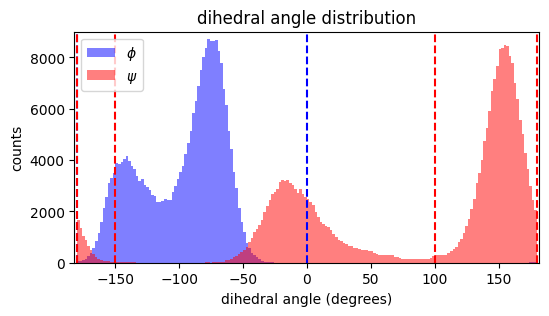

In [5]:
plt.figure(figsize=(6, 3))
plt.hist(phi.results.angles.T[0], bins=180, color='blue', alpha=0.5, label=r"$\phi$")
plt.hist(psi.results.angles.T[0], bins=180, color='red', alpha=0.5, label=r"$\psi$")
plt.xlim(-182,182)
plt.ylim(0, 9000)
plt.xlabel('dihedral angle (degrees)')
plt.ylabel('counts')
plt.title('dihedral angle distribution')
plt.vlines(-180, 0, 9000, colors='blue', linestyles='dashed')
plt.vlines(0, 0, 9000, colors='blue', linestyles='dashed')
plt.vlines(-180, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(-150, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(100, 0, 9000, colors='red', linestyles='dashed')
plt.vlines(180, 0, 9000, colors='red', linestyles='dashed')
plt.legend()
plt.show()

As indicated above, we use the range [-180,0] for $\phi$ (all frames in our trajectory).
For $\psi$, we select the ranges [-180,-150] or [100,180] which are split by periodic boundary conditions. This is taken into account below. 

Now, we select a consecutive segment of our trajectory which describes fluctuations around a single conformation.

In [6]:
trajIndices = np.arange(len(u.trajectory), dtype=int)   # default: use every frame

def longest_consecutive_indices(array1, lim1, array2, lim2, lim1alt=None, lim2alt=None):
    # array1, array2 = phi, psi time series ; lim* = allowed ranges (a box in phi/psi space)
    # the optional *alt ranges let a basin wrap across the +/-180 degree seam
    if lim1alt is None and lim2alt is None:                     # simple box, no wrapping
        mask = (array1 >= lim1[0]) & (array1 <= lim1[1]) & (array2 >= lim2[0]) & (array2 <= lim2[1])
    elif lim1alt is None:                                       # psi wraps, phi does not
        mask = (array1 >= lim1[0]) & (array1 <= lim1[1]) & (
            ((array2 >= lim2[0]) & (array2 <= lim2[1])) | ((array2 >= lim2alt[0]) & (array2 <= lim2alt[1]))
        )
    elif lim2alt is None:                                       # phi wraps, psi does not
        mask = (((array1 >= lim1[0]) & (array1 <= lim1[1])) | ((array1 >= lim1alt[0]) & (array1 <= lim1alt[1]))) & (
            (array2 >= lim2[0]) & (array2 <= lim2[1])
        )
    else:                                                       # both wrap
        mask = (
            (((array1 >= lim1[0]) & (array1 <= lim1[1])) | ((array1 >= lim1alt[0]) & (array1 <= lim1alt[1])))
            & (((array2 >= lim2[0]) & (array2 <= lim2[1])) | ((array2 >= lim2alt[0]) & (array2 <= lim2alt[1])))
        )

    # Walk the boolean mask and remember the LONGEST run of consecutive True values:
    max_len = 0;  max_start = -1                    # best run found so far
    current_len = 0;  current_start = -1            # run we are currently counting
    for i, ok in enumerate(mask):                   # scan frame by frame
        if ok:                                      # inside the basin
            if current_len == 0:                    # this frame starts a new run
                current_start = i
            current_len += 1                        # extend the current run
            if current_len > max_len:               # is this the longest so far
                max_len = current_len
                max_start = current_start
        else:                                       # left the basin, reset the counter
            current_len = 0
    if max_len == 0:                                # never inside the basin
        return None
    return np.arange(max_start, max_start + max_len, dtype=int)   # the winning frame indices

if USE_CONFORMATION_SEGMENT:
    phi = Dihedral([sel.residues[1].phi_selection()]).run()      # phi(t) of the central residue
    psi = Dihedral([sel.residues[1].psi_selection()]).run()      # psi(t) of the central residue

    trajIndices = longest_consecutive_indices(                   # longest single-basin stretch
        phi.results.angles.T[0], [-180, 0],                      # phi allowed range
        psi.results.angles.T[0], [100, 180],                     # psi main range
        lim2alt=[-180, -150]                                     # psi also allowed here (wrap)
    )
    if trajIndices is None:
        raise RuntimeError("No consecutive conformational segment found. Set USE_CONFORMATION_SEGMENT=False.")
    print(f"Basin segment length: {len(trajIndices)} frames = {len(trajIndices) * dt_ps:.3f} ps")
else:
    print("Using the FULL trajectory (no basin filtering).")



Basin segment length: 16734 frames = 66.936 ps


## Configuration for the modified FRESEAN approach

In [7]:
# [ADDED CORRECTION] 
# The corrected real-mode rank ceiling is min(nDOF, 2*nBlocks) at ordinary bins
# and min(nDOF, nBlocks) at DC and the even-N Nyquist endpoint.
# More overlapping blocks do not provide equally many independent samples.
# Hann amplitude weights and squared weights used in power estimates differ;
# exact equal weighting of all frames, including the ends, is not guaranteed.
#CONF

# Windowing
use_hann = True
overlap_frac = 0.75

#Note:  Overlap changes how many blocks can be cut from the same trajectory. First, the Hann window wastes the edges of each block. It fades to near-zero at both ends, so frames near a block's start and end barely count. Overlap fixes this.
#Second, more blocks mean more samples to build the modes from, and a better mode decomposition. Overlapping at 75% gives about 4 times as many blocks from the same data.
#Hann windows shifted by N/4 add up to a flat weight across the trajectory, so no frame is over- or under-counted. Beyond that, overlapping blocks start repeating the same data.

# FFT window length (frames)
# 4096 --> 16.384 ps window --> df ~ 0.061 ps^-1 (~2.0 cm^-1)
N = 4096

# Modes to keep per frequency bin
n_modes_keep = 7 #max would be = no of blocks


## Build the unwrap and align objects

- `unwrap` removes periodic-boundary jumps so an atom never teleports across the box.
- `align` superimposes every frame onto a reference structure. **`rotVel=1` is the critical flag**: when we rotate coordinates we must rotate the velocity vectors the same way. If we do not, the velocity correlations that FRESEAN is built on are corrupted.

We use the first frame of the chosen basin as the alignment reference.

In [8]:
for d in (OUTDIR, FFT_DIR, MODES_DIR, PLOTS_DIR):  
    os.makedirs(d, exist_ok=True)
print("Output folders ready under:", OUTDIR)

unwrap = pbc.unwrap(u)                             # unwrapper bound to our Universe

u.trajectory[int(trajIndices[0])]                  # jump to the FIRST frame of the basin segment
unwrap.single_frame()                              

ref_pos = sel.positions.copy()                     
align = fit.align(                                  
    u,                                             
    sel,                                           
    rotVel=1,                                       #   rotate velocities together with coordinates (critical)
    placeCOMInBox=0,                               #   do not re-wrap the centre of mass
    altRefPos=ref_pos                             
)
print("unwrap + align constructed (velocities rotated with rotVel=1)")

Output folders ready under: fresean_svd_ala_out
unwrap + align constructed (velocities rotated with rotVel=1)


## Build the time windows and the frequency axis

`make_windows` produces a list of index arrays, one per block. With 75 percent overlap each window slides forward by `N/4` frames, so neighbouring blocks share most of their data. More blocks means better averaging in the VDoS and the modes.

`np.fft.rfftfreq` gives the one-sided frequency grid (0 up to the Nyquist frequency) that matches `np.fft.rfft`.

In [9]:
# Original comment retained from the earlier complex formulation:
# you cannot have more modes than blocks
# [ADDED CORRECTION] For the real formulation, the ordinary-bin bound is 2*B;
# the real-only endpoints retain the B bound. Both are limited by nDOF.
# [CORRECTED] Report real-mode rank bounds; stop if no full FFT blocks exist.
def make_windows(n_frames_local, N, overlap_frac):
    step = int(round(N * (1.0 - overlap_frac)))         
    step = max(1, step)                                 # never zero
    starts = list(range(0, n_frames_local - N + 1, step))   # start index of every full-length window
    return [np.arange(s, s + N, dtype=int) for s in starts] # one index array per block

n_frames_local = len(trajIndices)                   # frames available in the basin segment
windows = make_windows(n_frames_local, N, overlap_frac)
nBlocks = len(windows)                              # number of overlapping blocks we will FFT

T_ps      = N * dt_ps                               # window length in ps
df_ps1    = 1.0 / T_ps                              # frequency resolution in ps^-1
f_nyq_ps1 = 1.0 / (2.0 * dt_ps)                     # highest resolvable frequency (Nyquist)

freqs_ps1 = np.fft.rfftfreq(N, d=dt_ps)             # one-sided frequency grid, ps^-1
nBins = len(freqs_ps1)                              # number of frequency bins

print(f"N={N} frames which is T={T_ps:.3f} ps per window")
print(f"df = {df_ps1:.6f} ps^-1  ({df_ps1 * 33.3564095:.3f} cm^-1)")
print(f"Nyquist= {f_nyq_ps1:.3f} ps^-1")
print("nBins=", nBins)
print("nBlocks=", nBlocks)
if nBlocks < 1:
    raise ValueError("No full FFT blocks fit in the selected trajectory segment.")
print("Real-mode rank ceiling at ordinary bins:", min(3 * sel.n_atoms, 2 * nBlocks))
print("Real-mode rank ceiling at DC/Nyquist:", min(3 * sel.n_atoms, nBlocks))


N=4096 frames which is T=16.384 ps per window
df = 0.061035 ps^-1  (2.036 cm^-1)
Nyquist= 125.000 ps^-1
nBins= 2049
nBlocks= 13
Real-mode rank ceiling at ordinary bins: 26
Real-mode rank ceiling at DC/Nyquist: 13


## Function to turn frame into a mass-weighted velocity vector

For each frame build one flat vector: `[sqrt(m1)*vx1, sqrt(m1)*vy1, sqrt(m1)*vz1, sqrt(m2)*vx2, ...]`, length `nDOF`.

The steps per frame are always: load the frame, unwrap it, align it (which rotates the velocities), then multiply by `sqrt(mass)` and flatten.


In [10]:
sqrt_m = np.sqrt(sel.masses).astype(np.float32)[:, None]   # column of sqrt(mass), shape (nAtoms, 1)
nAtoms = sel.n_atoms                                # atom count
nDOF   = 3 * nAtoms                                 # length of each velocity vector

def get_massweighted_vel_vector_for_local_frame(local_idx):
    frame_idx = int(trajIndices[local_idx])         # map "position within segment" -> real frame number
    u.trajectory[frame_idx]                         # load that frame (coordinates + velocities)
    unwrap.single_frame()                           # fix periodic-boundary jumps
    align.single_frame()                            # rotate coords AND velocities onto the reference

    v = sel.velocities.astype(np.float32, copy=False)   # (nAtoms, 3) velocities from the TRR
    v_mw = v * sqrt_m                               # multiply each atom velocity by sqrt(mass)
    return v_mw.reshape(-1)                         # flatten to a length-nDOF vector

x0 = get_massweighted_vel_vector_for_local_frame(0) # quick test on the first frame
print("velocity vector shape:", x0.shape, "dtype:", x0.dtype)
print("expected nDOF:", nDOF)


velocity vector shape: (66,) dtype: float32
expected nDOF: 66


## PASS A: FFT each block, save to disk, accumulate the VDoS

For every block:
1. stack its `N` mass-weighted velocity vectors into a matrix (`N x nDOF`),
2. multiply each time step by the Hann window,
3. FFT along the **time** axis to get `Xf` (`nBins x nDOF`), the velocity spectrum,
4. add `|Xf|^2` summed over DOF into the running VDoS,
5. save `Xf` to disk so PASS B can reuse it.

Saving each block to disk is what keeps memory flat when this is scaled to a big system.

In [11]:
def passA_write_block_ffts_and_vdos(overwrite=False):
    # pick the window shape (one number per time step, length N)
    if use_hann:
        w = np.hanning(N).astype(np.float32)     # Hann: fades in at the start, out at the end
    else:
        w = np.ones(N, dtype=np.float32)         # flat: every frame weighted equally (no taper)

    vdos_acc = np.zeros(nBins, dtype=np.float64) # running total of power at each frequency, summed over all blocks

    for b, win in enumerate(windows):            # b = block number, win = its frame indices
        outpath = os.path.join(FFT_DIR, f"block_{b:04d}.npy")   

        # CASE 1: we already computed this block on a previous run
        if (not overwrite) and os.path.exists(outpath):
            Xf = np.load(outpath, mmap_mode="r")                
            power = np.sum(np.abs(Xf)**2, axis=1, dtype=np.float64)   # |Xf|^2 summed over all DOF => power per frequency
            vdos_acc += power                                   

        # CASE 2: this block has not been computed yet 
        else:
            # build the block: one row per time step, one column per degree of freedom
            X = np.empty((N, nDOF), dtype=np.float32)          
            for ti, local_idx in enumerate(win):                # ti = row (time step), local_idx = which frame
                X[ti, :] = get_massweighted_vel_vector_for_local_frame(int(local_idx))  

            # apply the Hann window along time
            X *= w[:, None]                                    

            # FFT down the time axis: velocity-vs-time becomes velocity-vs-frequency
            Xf = np.fft.rfft(X, axis=0).astype(np.complex64, copy=False)   # shape (nBins, nDOF)

            # add this block's power to the running VDoS
            power = np.sum(np.abs(Xf)**2, axis=1, dtype=np.float64)        # power per frequency
            vdos_acc += power

            # save the spectrum so PASS B can reuse it, then free the memory
            np.save(outpath, Xf)                               # write Xf to disk
            del X, Xf                                          # drop these big arrays before the next block

        # print progress
        if (b + 1) % max(1, nBlocks // 5) == 0:                # every ~20% of the blocks
            print(f"PASS A: block {b + 1}/{nBlocks} done")

    # average the summed power over the number of blocks -> the raw VDoS
    return vdos_acc / float(nBlocks)


# run
print("Starting PASS A ...")
vdos = passA_write_block_ffts_and_vdos(overwrite=False)        # set overwrite=True to force a full recompute

# save 
np.save(os.path.join(OUTDIR, "freqs_ps1.npy"), freqs_ps1)     # x-axis: frequencies in ps^-1
np.save(os.path.join(OUTDIR, "vdos.npy"), vdos)               # y-axis: raw (un-normalized) VDoS
print("Saved freqs_ps1.npy and vdos.npy")

#monitor("after PASS A")                                        # report memory/CPU after this pass

Starting PASS A ...
PASS A: block 2/13 done
PASS A: block 4/13 done
PASS A: block 6/13 done
PASS A: block 8/13 done
PASS A: block 10/13 done
PASS A: block 12/13 done
Saved freqs_ps1.npy and vdos.npy


##### Estimate temperature from the velocities

We need `T` to normalise the VDoS against equipartition (each degree of freedom carries `1/2 kB T`). Temperature comes straight from kinetic energy: `<KE> = (nDOF/2) kB T`.

This function samples the whole trajectory (every 5th frame) rather than just the basin segment.

In [12]:
def estimate_T_from_trr(sample_stride=5):
    kB_md = 0.8314472                               # Boltzmann constant in amu*A^2/ps^2/K (MD units)
    K_acc = 0.0                                     # running sum of kinetic energy
    n_used = 0                                      # number of frames sampled

    for i, ts in enumerate(u.trajectory):           # walk the WHOLE trajectory
        if i % sample_stride != 0:                  # keep only every 5th frame (speed)
            continue
        v = sel.velocities                          # (nAtoms, 3)
        m = sel.masses[:, None]                     # (nAtoms, 1)
        K_frame = 0.5 * np.sum(m * v * v)           # kinetic energy of this frame
        K_acc += K_frame
        n_used += 1

    K_avg = K_acc / max(n_used, 1)                  # average kinetic energy
    nDOF_local = 3 * sel.n_atoms
    T_est = (2.0 * K_avg) / (nDOF_local * kB_md)    # invert equipartition to get T
    return T_est, K_avg, n_used

# NOTE: this leaves the trajectory pointer at the last frame. Harmless here because every later
# step re-seeks the exact frame it needs.
T_est, K_avg, n_used = estimate_T_from_trr(sample_stride=5)
print(f"T_est = {T_est:.2f} K   (from {n_used} sampled frames)")
print(f"K_avg = {K_avg:.4e}")

T_est = 299.66 K   (from 50001 sampled frames)
K_avg = 8.2220e+03


#### Normalise the VDoS to physical units

The raw VDoS has an arbitrary scale. Rescaling ensures its integrated area matches the equipartition target `nDOF * kB * T`, then convert to the FRESEAN velocity-spectrum convention (divide by the window time, factor `0.5`).

The `area_proxy` line accounts for the one-sided `rfft`: the DC bin is counted once, every other bin is counted twice (it stands in for its negative-frequency mirror).

<a id="change-normalization-note"></a>

**[ADDED NOTE — existing spectral normalization]**

**Note for the kinetic-energy check added below:** the existing VDoS plotting scale is retained here. It is not used to calculate any of the new kinetic energies. The final division by `T_ps` is not a standard power-spectral-density conversion, and the existing area expression counts the Nyquist endpoint twice for even `N`. Quantitative spectral-density normalization needs a separate correction. The direct time-domain energy check avoids these plotting-scale issues entirely.

In [13]:
kB_md = 0.8314472                               
nDOF  = 3 * sel.n_atoms

# One-sided rfft area: DC once, all other bins twice (mirror of the negative frequencies):
area_proxy = vdos[0] + 2.0 * np.sum(vdos[1:])   # "area" under the raw one-sided spectrum
target     = nDOF * kB_md * T_est               # equipartition target area
vdos_kbt   = vdos * (target / area_proxy)       # rescale the raw spectrum to hit the target

T_ps = N * dt_ps                                # window time (for the estimator prefactor)
vdos_fresean_norm = (vdos_kbt / T_ps) * 0.5    # velocity-spectrum normalisation

print(f"area_proxy (raw) = {area_proxy:.6e}")
print(f"target (nDOF kB T) = {target:.6e}")
print(f"T_ps (window)= {T_ps:.6f} ps")
print(f"peak( = {vdos_fresean_norm.max():.6e}")

area_proxy (raw) = 1.035570e+11
target (nDOF kB T) = 1.644410e+04
T_ps (window)= 16.384000 ps
peak( = 1.900820e+00


### Plot total VDOS

We tried to match this to the plot in the original tutorial. We convert the frequency axis from `ps^-1` to `cm^-1` (`1 ps^-1 = 33.3564 cm^-1`), smooth with a Gaussian whose width is set in `cm^-1`, and show only the low-frequency region (`<= 200 cm^-1`). Output is SVG (vector).


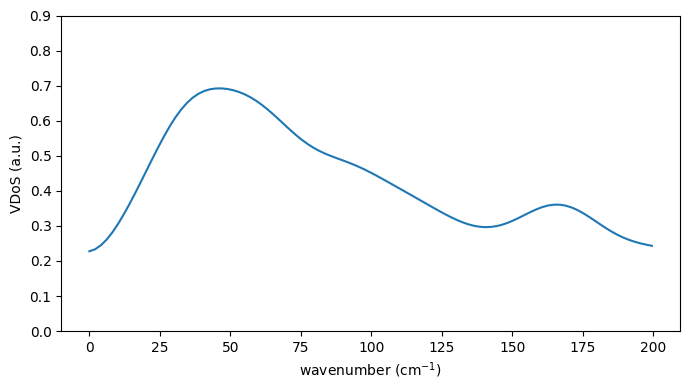

Saved fresean_svd_ala_out/plots/vdos_smooth.svg


In [14]:
from scipy.ndimage import gaussian_filter1d   # smoothing for a readable curve

ps1_to_cm1 = 33.3564095                         # 1 ps^-1 = 33.3564 cm^-1
freqs_cm1 = freqs_ps1 * ps1_to_cm1              # frequency axis in wavenumbers
df_cm1 = freqs_cm1[1] - freqs_cm1[0]            # bin spacing in cm^-1

sigma_cm1 = 10.0                                # smoothing width in cm^-1
sigma_bins = sigma_cm1 / df_cm1                 # convert that width into a number of bins

vdos_smooth = gaussian_filter1d(vdos_fresean_norm.astype(float), sigma=sigma_bins)  # smoothed VDoS

mask = freqs_cm1 <= 200.0                       # low-frequency window to display
plt.figure(figsize=(7, 4))
plt.plot(freqs_cm1[mask], vdos_smooth[mask])
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("VDoS (a.u.)")
plt.ylim(0, 0.9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "vdos_smooth.svg"))   # vector output
plt.show()
print("Saved", os.path.join(PLOTS_DIR, "vdos_smooth.svg"))

<a id="change-pass-b"></a>

**[CORRECTED — real spatial modes and rank bounds]**

## ADDED CORRECTION: PASS B with real spatial modes
At one frequency bin we build a matrix `F`:

- shape `nDOF x nBlocks` (rows = degrees of freedom, columns = blocks)
- each **column** is one block's complex velocity spectrum at this frequency

We want real spatial directions that describe collective motion. So first we put the real and imaginary parts next to each other:

    A = [F.real, F.imag]     shape: nDOF x (2*nBlocks)

Both parts contain information about the motion. The real part gives the cosine pattern and the imaginary part gives the sine pattern (with the FFT sign convention). We keep both, then find the **left singular vectors of A**, the matrix called `U` in the SVD `A = U S Vt`.
So the entire goal of PASS B is: **get real U**.

### Why the large matrix might be memory heavy for a capsid

One way to get `U` is to diagonalize `A @ A.T`. Its eigenvectors are exactly the left singular vectors. But,

    A @ A.T  is  nDOF x nDOF
    capsid: about 102,000 x 102,000

### Solution:

`A` is skinny: far more rows than columns. At an ordinary frequency it has `2*nBlocks` columns, so there can be at most that many nonzero singular values. At zero frequency and the even-N Nyquist endpoint the imaginary part is zero, and the bound is only `nBlocks`. Both bounds are also capped by `nDOF`.

### The Gram matrix

Flip the product. Instead of `A @ A.T` (big), form `A.T @ A` (small):

    A.T @ A  is  (2*nBlocks) x (2*nBlocks) at ordinary frequencies
    At the real-only endpoints we use nBlocks x nBlocks.

This is the **Gram matrix**, `G`. It compares all the real/imaginary block patterns with each other at this frequency. It is one matrix for that frequency, not one matrix per block.

### Why flipping the order keeps the same modes

Write the SVD `A = U S Vt`. The two products share the same nonzero squared singular values:

    A @ A.T = U S^2 Ut     eigenvectors = U (the spatial modes)
    A.T @ A = V S^2 Vt     eigenvectors = V (weights in the smaller space)

`U` and `V` are linked through `A`. If we get `V` and `S` from the small matrix, we can rebuild the spatial modes:

    U = A @ V / S

Take `A`, multiply by the small eigenvectors `V`, and divide each resulting column by its singular value. We only divide by nonzero singular values. The result is a set of real unit-length spatial modes.

### One numerical caveat

The Gram method is most reliable for well-resolved singular values. Very weak modes can lose accuracy compared with direct SVD. The code uses double precision for the calculation, filters roundoff-level values, and checks orthogonality. A direct thin SVD of A is also possible without constructing the large nDOF x nDOF matrix.


## PASS B: frequency-resolved modes via the Gram matrix trick: 
At one frequency bin we build a matrix `F`:

- shape `nDOF x nBlocks` (rows = degrees of freedom, columns = blocks)
- each **column** is one block's velocity spectrum at this frequency

We want the dominant spatial patterns in those columns. Those patterns are the collective modes at this frequency, and mathematically they are the **left singular vectors of `F`**, the matrix called `U` in the SVD `F = U S Vh`.
So the entire goal of PASS B is: **get `U`**.

### Why the direct route might be memory heavy for a capsid

The textbook way to get `U` is to diagonalize `F Fh`. Its eigenvectors are exactly `U`. But ,

    F Fh  is  nDOF x nDOF
    capsid: 102,000 x 102,000  

### Solution:

`F` is skinny: far more rows than columns (100,000 rows, ~197 columns). A matrix with only `nBlocks` columns can hold at most `nBlocks` independent directions. So even though `U` lives in 100,000-dimensional space, **only `nBlocks` of its columns can be non-zero**. The rest are empty (zero singular value).


### The Gram matrix

Flip the product. Instead of `F Fh` (big), form `Fh F` (small):

    Fh F  is  nBlocks x nBlocks
    capsid: 197 x 197  ->  well under 1 MB

This is the **Gram matrix**, `G`. It is one matrix built from all blocks at once; it encodes how every block relates to every other block at this frequency. The blocks are its rows and columns (not one Gram matrix per block).

### Why flipping the order keeps the same modes

Write the SVD `F = U S Vh`. The two products share the same singular values `S`:

    F Fh = U S^2 Uh     eigenvectors = U (the modes)   ... huge
    Fh F = V S^2 Vh     eigenvectors = V               ... tiny

`U` and `V` are two halves of the same decomposition, linked through `F`. So if we get `V` and `S` from the small matrix, we have not lost `U`, we can rebuild it:

    U = F V / S

Take the original `F`, multiply by the small `V`, divide by the singular values, and get the modes. Cheap: `F V` is `F` times a `nBlocks`-column matrix, and the division is elementwise.


### One numerical caveat

 The strong low-frequency modes (most of the power) are unaffected. The weak, near-degenerate modes at the bottom of the ranked list come out noisier than a direct SVD would give. If you ever care about those weak modes specifically, use a direct SVD instead; for the dominant modes the Gram route is fine.

<a id="change-svd-code"></a>

**[ADDED — missing SVD implementation explained; code immediately below]**

### The executable SVD step

The explanation above describes the calculation; the function below now performs it.

1. At bin `k`, take one Fourier vector from each block and place these vectors next to each other in `F`.
2. Put the real and imaginary parts next to each other in `A = [F.real, F.imag]`. These are real spatial patterns from the same blocks.
3. Build `G = A.T @ A`. This compares those patterns with each other and is at most `2*nBlocks x 2*nBlocks`.
4. `np.linalg.eigh(G)` gives the small-matrix eigenvectors `V` and eigenvalues `mu`.
5. Take `sqrt(mu)` to get the singular values `S`.
6. Recover the spatial modes with `U = A @ V / S`, then save one mode per row.

**So where is the SVD?** It is carried out through the Gram eigendecomposition and the recovery of `U`. There does not need to be a call named `svd`. A direct thin SVD, `np.linalg.svd(A, full_matrices=False)`, would give the same nonzero singular values and mode subspaces, apart from numerical error. Signs are arbitrary, and equal singular values can give different orthonormal combinations within the same subspace.

The files `sing_k....npy` contain singular values of **A**. Squaring them and dividing by `nBlocks` gives the eigenvalues of the **raw real block-averaged** matrix `A @ A.T / nBlocks`. The denominator is still `nBlocks`, not `2*nBlocks`: the real and imaginary columns came from the same B blocks. Any common spectral normalization factor would then multiply all those eigenvalues; it would not change the modes.

**What the complex-vector correction does:** `F.real` and `F.imag` hold the cosine and sine patterns. Keeping both gives

$$A A^T = F_R F_R^T + F_I F_I^T = \operatorname{Re}(F F^\dagger).$$

The total power (the trace) is preserved. We now find real orthonormal directions that maximize projected power over **real** directions, consistent with the real equilibrium FRESEAN interpretation.

At DC (zero frequency), and at Nyquist when N is even, the Fourier coefficients are real. Their imaginary columns are zero, so the code uses just `F.real` at those endpoints. At other bins the code uses both parts. The saved mode files now have a real `float32` dtype instead of `complex64`; their shape remains `(nEff, nDOF)`.

**What the block count means:** at most `min(nDOF, 2*nBlocks)` singular values can be nonzero at ordinary bins, and at most `min(nDOF, nBlocks)` at the real-only endpoints. It is the singular values that become zero, not the unused unit vectors in a full basis. This rank ceiling is a property of the estimate; it does not prove that the molecule has only that many physical motions. Overlapping blocks also share observations, so increasing overlap does not add equally many independent samples.

The Gram route can lose accuracy for very small singular values because it squares the condition number. We discard values at the roundoff level and check the orthogonality of the recovered modes. This is a numerical check, not a test of their physical interpretation.

In [15]:
# [ADDED SVD CODE] Previously missing PASS B: Gram eigendecomposition, mode recovery, and saving.
# [COMPLEX-VECTOR CORRECTION] Use both F.real and F.imag for real spatial modes; DC/Nyquist use F.real.
def passB_write_modes(overwrite=True):
    # One Fourier vector per block, at ONE frequency at a time.
    # Keep both Fourier parts, but find REAL spatial directions.
    if nBlocks < 1 or n_modes_keep < 1:
        raise ValueError("Need at least one block and one requested mode.")
    os.makedirs(MODES_DIR, exist_ok=True)
    blocks = [np.load(os.path.join(FFT_DIR, f"block_{b:04d}.npy"),
                      mmap_mode="r", allow_pickle=False) for b in range(nBlocks)]
    if any(block.shape != (nBins, nDOF) for block in blocks):
        raise ValueError("FFT file shape differs from this run. Recompute PASS A.")

    for k in range(nBins):
        mode_path = os.path.join(MODES_DIR, f"modes_k{k:04d}.npy")
        sing_path = os.path.join(MODES_DIR, f"sing_k{k:04d}.npy")
        if not overwrite and os.path.exists(mode_path) and os.path.exists(sing_path):
            continue

        F = np.column_stack([block[k, :] for block in blocks]).astype(np.complex128)
        # F: nDOF x nBlocks. Each column is one block at frequency k.
        if not np.all(np.isfinite(F)):
            raise ValueError(f"Non-finite Fourier coefficients at bin {k}.")
        # A contains the cosine and sine patterns as separate REAL columns.
        # A @ A.T = real(F @ F.conj().T). Do not discard F.imag.
        endpoint = k == 0 or (N % 2 == 0 and k == nBins - 1)
        A = F.real.copy() if endpoint else np.concatenate((F.real, F.imag), axis=1)
        G = A.T @ A                         # B x B at endpoints; 2B x 2B otherwise
        G = 0.5 * (G + G.T)                # remove roundoff asymmetry
        mu, V = np.linalg.eigh(G)           # mu = squared singular values
        order = np.argsort(mu)[::-1]        # largest contribution first
        mu, V = mu[order], V[:, order]

        # Do not divide by zero, or by eigenvalues at roundoff level.
        tol = np.finfo(np.float64).eps * max(A.shape) * max(float(mu[0]), 0.0)
        if np.any(mu < -tol):
            raise RuntimeError(f"Unexpected negative Gram eigenvalue at bin {k}.")
        keep = np.flatnonzero(mu > tol)[:min(n_modes_keep, *A.shape)]
        singular = np.sqrt(mu[keep])
        U = (A @ V[:, keep]) / singular[None, :]  # recover REAL spatial modes
        # U columns are the left singular vectors; files store one mode per ROW.
        if len(keep):
            error = np.max(np.abs(U.T @ U - np.eye(len(keep))))
            if error > 1e-5:
                raise RuntimeError(f"Mode orthogonality lost at bin {k}; use direct SVD.")
        np.save(mode_path, U.T.astype(np.float32))
        np.save(sing_path, singular.astype(np.float64))
        if (k + 1) % max(1, nBins // 5) == 0 or k == nBins - 1:
            print(f"PASS B: bin {k + 1}/{nBins}, saved {len(keep)} modes")
    print("PASS B complete. Mode and singular-value files are under:", MODES_DIR)


# Recompute modes so this notebook does not depend on previously saved answers.
passB_write_modes(overwrite=True)

PASS B: bin 409/2049, saved 7 modes
PASS B: bin 818/2049, saved 7 modes
PASS B: bin 1227/2049, saved 7 modes
PASS B: bin 1636/2049, saved 7 modes
PASS B: bin 2045/2049, saved 7 modes
PASS B: bin 2049/2049, saved 7 modes
PASS B complete. Mode and singular-value files are under: fresean_svd_ala_out/modes_by_bin


#### Quick sanity check: load one bin’s modes

In [16]:
k_star = 10                                     # any bin index you like for the check
modes_star = np.load(os.path.join(MODES_DIR, f"modes_k{k_star:04d}.npy"))  # (nEff, nDOF)
sing_star  = np.load(os.path.join(MODES_DIR, f"sing_k{k_star:04d}.npy"))   # (nEff,)

print("k*   =", k_star, " f* =", float(freqs_ps1[k_star]), "ps^-1")
print("modes_star:", modes_star.shape, modes_star.dtype)
print("sing_star :", sing_star.shape, sing_star.dtype)

# Load every block's FFT into RAM. 
Xf_blocks = np.empty((nBlocks, nBins, nDOF), dtype=np.complex64)
for b in range(nBlocks):
    Xf_blocks[b] = np.load(os.path.join(FFT_DIR, f"block_{b:04d}.npy"), mmap_mode="r")
print("Xf_blocks:", Xf_blocks.shape, Xf_blocks.dtype)


k*   = 10  f* = 0.6103515625 ps^-1
modes_star: (7, 66) float32
sing_star : (7,) float64
Xf_blocks: (13, 2049, 66) complex64


## Mode contribution curves

Take the modes found at one frequency `k*` and ask how much of the motion at every frequency they explain. For each mode `m` and bin `k` we project the mode - i.e. take the inner product - onto every block's spectrum, square the overlap, and average over blocks.Squaring because inner product is a complex number.

In [17]:
def mode_contrib_curves_from_modes_at_kstar(modes_kstar, Xf_blocks):
    # a[m, b, k] = <mode_m , F_k(:, b)> = sum over DOF of conj(mode_m) * Xf_blocks[b, k, :]
    a = np.tensordot(np.conjugate(modes_kstar), Xf_blocks, axes=([1], [2]))   # (nModes, nBlocks, nBins)
    mode_curves = np.mean((a.real * a.real + a.imag * a.imag), axis=1)        # |overlap|^2 averaged over blocks -> (nModes, nBins)
    sum_modes = np.sum(mode_curves, axis=0)                                   # total across kept modes -> (nBins,)
    return mode_curves.astype(np.float64), sum_modes.astype(np.float64)

Using k*=25 -> f*=50.90 cm^-1
plotting 7 modes
scale factor raw -> fresean_style: 4.845969625547283e-09


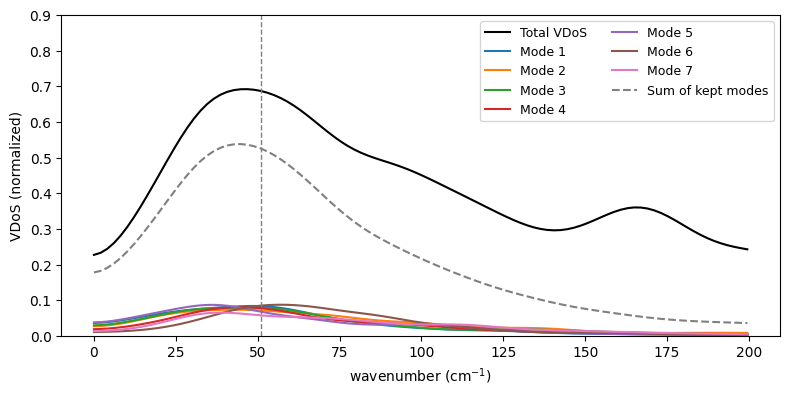

Saved fresean_svd_ala_out/plots/mode_contributions_k0025.svg
Fraction of the k* peak captured by the top 7 modes: 0.929


In [18]:
# [CORRECTED] The existing smoothing-off branch now defines vdos_plot.
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

target_cm1   = 50.0        # which peak (in cm^-1) to take the modes from
n_modes_plot = None        # None = use n_modes_keep
USE_SMOOTH   = True        # smooth curves for readability
sigma_cm1    = 10.0        # smoothing width (match the VDoS plot)
xmax_cm1     = 200.0       # x-axis limit

# frequency axis + display mask 
ps1_to_cm1 = 33.3564095
freqs_cm1 = freqs_ps1 * ps1_to_cm1
mask = freqs_cm1 <= xmax_cm1
df_cm1 = freqs_cm1[1] - freqs_cm1[0]
sigma_bins = sigma_cm1 / df_cm1

# total VDoS for the black background curve 
if USE_SMOOTH:
    vdos_plot = gaussian_filter1d(vdos_fresean_norm.astype(float), sigma=sigma_bins)
else:
    vdos_plot = vdos_fresean_norm

#  reload block FFTs 
Xf_blocks = np.empty((nBlocks, nBins, nDOF), dtype=np.complex64)
for b in range(nBlocks):
    Xf_blocks[b] = np.load(os.path.join(FFT_DIR, f"block_{b:04d}.npy"), mmap_mode="r")

# find the bin nearest the requested peak 
k_star = int(np.argmin(np.abs(freqs_cm1 - target_cm1)))
f_star_cm1 = float(freqs_cm1[k_star])
print(f"Using k*={k_star} -> f*={f_star_cm1:.2f} cm^-1")

# load the modes computed at that bin
modes_star = np.load(os.path.join(MODES_DIR, f"modes_k{k_star:04d}.npy"))   # (nEff, nDOF)
if n_modes_plot is None:
    n_modes_plot = min(int(n_modes_keep), modes_star.shape[0])
else:
    n_modes_plot = min(int(n_modes_plot), modes_star.shape[0])
modes_star = modes_star[:n_modes_plot]             # keep the top few
print("plotting", n_modes_plot, "modes")

# project those modes onto every bin (unnormalised) 
a = np.tensordot(np.conjugate(modes_star), Xf_blocks, axes=([1], [2]))      # (nModes, nBlocks, nBins)
mode_curves_raw = np.mean((a.real * a.real + a.imag * a.imag), axis=1)      # (nModes, nBins)
sum_modes_raw   = np.sum(mode_curves_raw, axis=0)                           # (nBins,)

# put the mode curves on the SAME scale as vdos_fresean_norm
vdos_raw = np.load(os.path.join(OUTDIR, "vdos.npy"))                        # raw PASS A spectrum
lo, hi = 5, min(200, len(vdos_raw))                                        # ignore DC and the far tail
scalar = float(np.median(vdos_fresean_norm[lo:hi] / np.maximum(vdos_raw[lo:hi], 1e-30)))  # one scale factor
print("scale factor raw -> fresean_style:", scalar)
mode_curves = mode_curves_raw * scalar
sum_modes   = sum_modes_raw   * scalar

#  optional smoothing (same Gaussian as the VDoS) 
if USE_SMOOTH:
    mode_curves_s = np.vstack([gaussian_filter1d(mode_curves[m].astype(float), sigma=sigma_bins) for m in range(n_modes_plot)])
    sum_modes_s   = gaussian_filter1d(sum_modes.astype(float), sigma=sigma_bins)
else:
    mode_curves_s = mode_curves
    sum_modes_s   = sum_modes

# plot 
plt.figure(figsize=(8, 4))
plt.plot(freqs_cm1[mask], vdos_plot[mask], color="black", label="Total VDoS")   # background total
for m in range(n_modes_plot):
    plt.plot(freqs_cm1[mask], mode_curves_s[m, mask], label=f"Mode {m + 1}")     # each mode's curve
plt.plot(freqs_cm1[mask], sum_modes_s[mask], color="gray", linestyle="--", label="Sum of kept modes")
plt.axvline(f_star_cm1, color="gray", linestyle="--", linewidth=1)               # mark k*
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("VDoS (normalized)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.ylim(0, 0.9)
plt.savefig(os.path.join(PLOTS_DIR, f"mode_contributions_k{k_star:04d}.svg"))
plt.show()
print("Saved", os.path.join(PLOTS_DIR, f"mode_contributions_k{k_star:04d}.svg"))

# how much of the peak do these modes capture?
frac = float(sum_modes[k_star] / max(vdos_fresean_norm[k_star], 1e-30))
print(f"Fraction of the k* peak captured by the top {n_modes_plot} modes: {frac:.3f}")


## Save results

In [19]:
# [CORRECTED] Save vdos_fresean_norm; the old vdos_fresean_style name was undefined.
np.savez(                                       # compact results bundle
    os.path.join(OUTDIR, "svd_results.npz"),
    freqs_cm1=freqs_cm1,                        # frequency axis in cm^-1
    vdos=vdos_fresean_norm,                    # normalised total VDoS
    mode_curves=mode_curves_s,                  # smoothed per-mode contribution curves
    sum_modes=sum_modes_s,                      # smoothed sum of kept modes
)
print("Saved svd_results.npz")

np.savez(                                       # verbose bundle that reproduces the exact plot
    os.path.join(OUTDIR, "svd_results_exact_plot.npz"),
    freqs_cm1=freqs_cm1,
    vdos_raw=vdos_fresean_norm,
    vdos_smooth=vdos_smooth,
    mode_curves_raw=mode_curves,
    mode_curves_smooth=mode_curves_s,
    sum_modes_raw=sum_modes,
    sum_modes_smooth=sum_modes_s,
    target_cm1=target_cm1,
    k_star=k_star,
    f_star_cm1=f_star_cm1,
    n_modes_plot=n_modes_plot,
    sigma_cm1=sigma_cm1,
    use_smooth=USE_SMOOTH,
)
print("Saved svd_results_exact_plot.npz")
print("All done.")

Saved svd_results.npz
Saved svd_results_exact_plot.npz
All done.


<a id="change-ke-check"></a>

**[ADDED — Matthias's requested kinetic-energy check]**

## Kinetic-energy check requested by Matthias

Do the combined degrees of freedom obtained from SVD carry a sensible amount of thermal kinetic energy? Capturing a large fraction of a spectral peak does not answer this question by itself.

### What are we measuring?

Take one mode and keep its direction fixed. At every frame, project the original mass-weighted velocity vector onto that direction. The result is one number per frame: the velocity along that collective direction. Square these numbers, average them, and multiply by `0.5` to get its average kinetic energy.

For a real mode `u_j`,

$$\dot q_j(t) = u_j^T x(t), \qquad x_i(t) = \sqrt{m_i}\,v_i(t)$$

$$\langle K_j\rangle = \frac{1}{2}\langle \dot q_j(t)^2\rangle.$$

Here `v_i(t)` is an original velocity component, `m_i` is its atom/bead mass, and `u_j` is the saved unit mode vector. The dot product measures how much of the frame's motion lies along that mode. The mass is already included in `x`, so we do not multiply by a mass again after projection.

**What is being summed?** In the projection, we multiply each original mass-weighted velocity component by its mode entry and then sum over the original components. This gives one **velocity**, not an energy yet. Squaring that projected velocity and multiplying by `0.5` gives the energy for **that one collective direction**. Adding the energies of all directions in a complete real orthonormal basis recovers the total kinetic energy. Adding only retained modes gives the energy in that retained subspace. Modes selected at different frequencies are not generally mutually orthogonal; do not sum energies across frequency-specific mode sets and call that the total kinetic energy.

**The mode is selected at one frequency, but its kinetic energy is calculated from the full velocity fluctuations along that fixed direction.** 
### What do we compare it with?

- **Expected thermal energy:** `0.5 * kB * T_ref` per scalar coordinate. At 300 K this is about **1.247 kJ/mol** (the molar equivalent of `0.5*kB*T`). `T_ref` is entered explicitly instead of fitted to the mode energies.
- **Original components:** compute `0.5 * mean(x_i(t)^2)` for every original Cartesian component, then report their mean and range. The comparison uses the same frames and alignment.
- **Center of mass:** compute the mass-weighted COM velocity of the whole selected molecule, then its kinetic energy separately along x, y, and z. These are three scalar coordinates. Their sum is the total translational COM energy; we do not compare that sum with a single mode.

### Which modes are checked?

The corrected PASS B produces real modes at every frequency, so the same real-coordinate energy test can now be applied at zero and nonzero frequency. The default checks the modes at zero frequency and at the bin selected for the VDoS contribution plot: `KE_BINS = [0, k_star]`.

An older complex mode file is not silently converted by dropping its imaginary part. The energy function rejects complex mode files and asks you to rerun the corrected PASS B. This prevents mixing the old and corrected formulations.

In [20]:
# [ADDED KE CHECK] Project original velocities onto fixed real modes and average 0.5*qdot**2.
def kinetic_energy_check(modes_by_bin, local_indices, T_ref=300.0):
    # x contains sqrt(mass)*velocity, so 1/2*x^2 is already kinetic energy.
    # All energies below use ORIGINAL velocities: no Hann, FFT, or VDoS rescaling.
    local_indices = np.asarray(local_indices, dtype=int)
    if local_indices.ndim != 1 or len(local_indices) == 0:
        raise ValueError("Choose a non-empty, one-dimensional frame selection.")
    if np.any(local_indices < 0) or np.any(local_indices >= len(trajIndices)):
        raise ValueError("Frame indices must refer to positions within trajIndices.")
    if len(np.unique(local_indices)) != len(local_indices):
        raise ValueError("Count each selected trajectory frame only once.")
    if not np.isfinite(T_ref) or T_ref <= 0:
        raise ValueError("Reference temperature must be positive.")

    masses = np.asarray(sel.masses, dtype=np.float64)
    if len(masses) * 3 != nDOF or np.any(~np.isfinite(masses)) or np.any(masses <= 0):
        raise ValueError("Need positive masses matching the analyzed velocity components.")
    sqrt_mass = np.sqrt(masses)[:, None]
    # Reject old complex mode files instead of silently dropping their imaginary parts.
    if any(np.iscomplexobj(M) for M in modes_by_bin.values()):
        raise ValueError("Complex mode files found. Run the corrected real-mode PASS B first.")
    modes = {int(k): np.asarray(M, dtype=np.float64) for k, M in modes_by_bin.items()}
    if not modes:
        raise ValueError("Load at least one set of modes.")
    for k, M in modes.items():
        if M.ndim != 2 or M.shape[1] != nDOF or M.shape[0] == 0:
            raise ValueError(f"Modes at bin {k} have the wrong shape or are empty.")
        if not np.all(np.isfinite(M)):
            raise ValueError(f"Non-finite mode entries at bin {k}.")
        error = np.max(np.abs(M @ M.T - np.eye(len(M))))
        if error > 1e-5:
            raise ValueError(f"Modes at bin {k} are not orthonormal. Error = {error:g}")

    original_sum = np.zeros(nDOF, dtype=np.float64)
    com_sum = np.zeros(3, dtype=np.float64)
    projected_sum = {k: np.zeros(len(M), dtype=np.float64) for k, M in modes.items()}
    for number, local_idx in enumerate(local_indices, start=1):
        # This existing helper reloads, unwraps, aligns, and mass-weights the frame.
        x = get_massweighted_vel_vector_for_local_frame(int(local_idx)).astype(np.float64)
        if x.shape != (nDOF,) or not np.all(np.isfinite(x)):
            raise ValueError(f"Invalid velocities at local frame {local_idx}.")
        original_sum += x * x
        for k, M in modes.items():
            qdot = M @ x                    # one REAL projected velocity per saved mode
            projected_sum[k] += qdot * qdot
        # sqrt(total mass)*V_COM, using the same selected atoms and aligned frame.
        com_mw = np.sum(x.reshape(-1, 3) * sqrt_mass, axis=0) / np.sqrt(masses.sum())
        com_sum += com_mw * com_mw
        if number % max(1, len(local_indices) // 5) == 0:
            print(f"Kinetic-energy check: frame {number}/{len(local_indices)}")

    # MDAnalysis uses amu and A/ps here: 1 amu*A^2/ps^2 = 0.01 kJ/mol.
    factor = 0.5 * 0.01 / len(local_indices)
    kB_md = 0.8314472
    return {
        "original": original_sum * factor,
        "com": com_sum * factor,
        "modes": {k: values * factor for k, values in projected_sum.items()},
        "norm2": {k: np.sum(np.abs(M) ** 2, axis=1) for k, M in modes.items()},
        "expected": 0.5 * kB_md * T_ref * 0.01,
        "n_frames": len(local_indices),
        "T_ref": float(T_ref),
    }

<a id="change-ke-run"></a>

**[ADDED — run and save the energy comparison]**

### Run the check and save the comparison

The default uses every frame in the already selected basin and checks zero frequency plus the frequency chosen for the mode-contribution plot. This is a check on the same data used to learn the modes, including any unused tail after the final full FFT block. It does not represent an independent-trajectory test. The full-basin result can differ slightly from a check reconstructed from only the cached FFT coverage.

The function streams the trajectory one frame at a time, so it does not load the whole velocity trajectory into memory. `KE_STRIDE` can be increased for a quick check; use 1 for the complete selected segment. The CSV files contain every original Cartesian component, the three COM components, and every tested mode. The settings file records the original frame indices used.

In [21]:
# [ADDED KE COMPARISON] Run the check and save original-component, COM, and mode energies.
import csv

KE_BINS = [0, k_star]          # zero frequency AND the modes selected for the VDoS plot
# KE_BINS = [0]               # use this for just the zero-frequency check
KE_T_REF = 300.0               # independent reference temperature for this tutorial
KE_STRIDE = 1                  # use each selected frame once; increase for a quick check

ke_modes = {
    k: np.load(os.path.join(MODES_DIR, f"modes_k{k:04d}.npy"), allow_pickle=False)
    for k in dict.fromkeys(KE_BINS)
}
ke_indices = np.arange(0, len(trajIndices), KE_STRIDE, dtype=int)
ke = kinetic_energy_check(ke_modes, ke_indices, T_ref=KE_T_REF)

print(f"\nFrames checked: {ke['n_frames']} (selected basin, same data used to learn modes)")
print(f"Expected energy per scalar coordinate: {ke['expected']:.6f} kJ/mol")
print(f"Original component mean: {ke['original'].mean():.6f} kJ/mol")
print(f"Original component range: {ke['original'].min():.6f} to {ke['original'].max():.6f}")
print("Whole-selection COM components x, y, z (kJ/mol):", ke["com"])

mode_rows = []
for k, energies in ke["modes"].items():
    kind = "real coordinate"
    print(f"\nBin {k}, {freqs_ps1[k] * 33.3564095:.3f} cm^-1: {kind}")
    print("Mode    K (kJ/mol)    K / expected    K / original mean")
    for j, energy in enumerate(energies):
        # Keep the saved mode norms. Do not force the measured energy to the target.
        expected = ke["expected"] * ke["norm2"][k][j]
        print(f"{j+1:4d}    {energy:10.6f}    {energy/expected:12.6f}    {energy/ke['original'].mean():17.6f}")
        mode_rows.append([k, freqs_ps1[k], j+1, kind, ke["norm2"][k][j],
                          energy, energy/expected, energy/ke["original"].mean()])

check_dir = os.path.join(OUTDIR, "kinetic_energy_check")
os.makedirs(check_dir, exist_ok=True)
with open(os.path.join(check_dir, "mode_kinetic_energies.csv"), "w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["bin", "frequency_ps^-1", "mode", "interpretation", "mode_norm_squared",
                     "K_kJ_per_mol", "K_over_expected", "K_over_original_mean"])
    writer.writerows(mode_rows)
with open(os.path.join(check_dir, "reference_kinetic_energies.csv"), "w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["type", "component", "K_kJ_per_mol", "K_over_expected"])
    for i, energy in enumerate(ke["original"]):
        writer.writerow(["original", f"selected_atom_{i//3+1}_{'xyz'[i%3]}", energy, energy/ke["expected"]])
    for axis, energy in zip("xyz", ke["com"]):
        writer.writerow(["whole_selection_COM", axis, energy, energy/ke["expected"]])
np.savez(os.path.join(check_dir, "check_settings.npz"),
         original_trajectory_frames=trajIndices[ke_indices], bins=np.array(list(ke_modes)),
         temperature_K=KE_T_REF, n_frames=ke["n_frames"], expected_kJ_per_mol=ke["expected"],
         original_mean_kJ_per_mol=ke["original"].mean(), same_data_check=True)
print("\nSaved kinetic-energy tables and settings under:", check_dir)

Kinetic-energy check: frame 3346/16734
Kinetic-energy check: frame 6692/16734
Kinetic-energy check: frame 10038/16734
Kinetic-energy check: frame 13384/16734
Kinetic-energy check: frame 16730/16734

Frames checked: 16734 (selected basin, same data used to learn modes)
Expected energy per scalar coordinate: 1.247171 kJ/mol
Original component mean: 1.245959 kJ/mol
Original component range: 1.091190 to 1.535538
Whole-selection COM components x, y, z (kJ/mol): [1.13226127 1.24075646 1.19355215]

Bin 0, 0.000 cm^-1: real coordinate
Mode    K (kJ/mol)    K / expected    K / original mean
   1      1.325818        1.063061             1.064094
   2      1.229566        0.985884             0.986843
   3      1.226311        0.983274             0.984230
   4      1.142842        0.916348             0.917239
   5      1.347250        1.080245             1.081295
   6      1.223281        0.980845             0.981799
   7      1.186704        0.951517             0.952442

Bin 25, 50.898 cm^

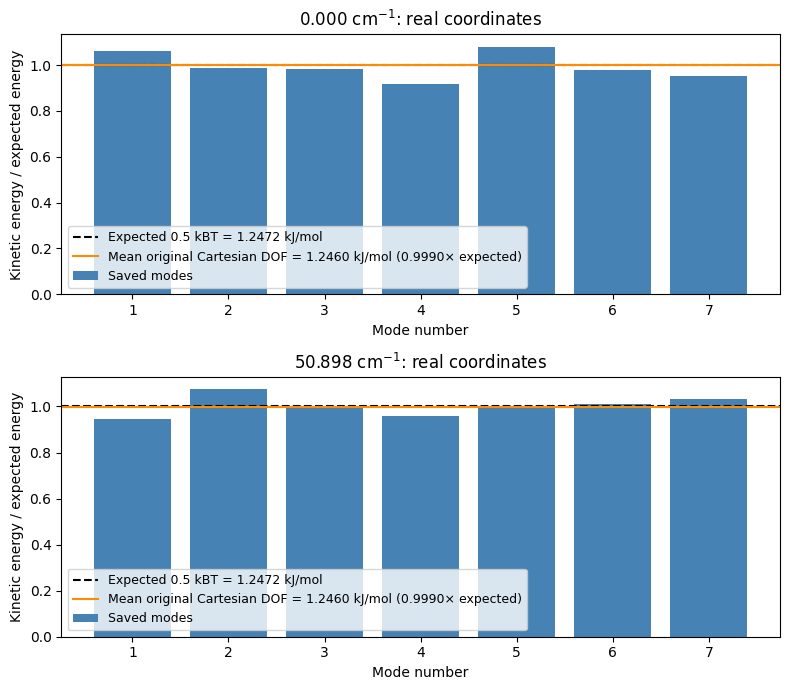

In [23]:
# [ADDED KE PLOT] Compare each mode with 0.5*kB*T and the mean original Cartesian-DOF energy.
# All values are shown on the same normalized scale.
fig, axes = plt.subplots(len(ke["modes"]), 1, figsize=(8, 3.5 * len(ke["modes"])), squeeze=False)
expected_val = ke["expected"]
original_mean_val = ke["original"].mean()
original_mean_ratio = original_mean_val / expected_val

for ax, (k, energies) in zip(axes.flat, ke["modes"].items()):
    ratios = energies / (expected_val * ke["norm2"][k])
    ax.bar(np.arange(1, len(energies) + 1), ratios, color="steelblue", label="Saved modes")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.5, label=f"Expected 0.5 kBT = {expected_val:.4f} kJ/mol")
    ax.axhline(original_mean_ratio, color="darkorange", linewidth=1.5, label=f"Mean original Cartesian DOF = {original_mean_val:.4f} kJ/mol ({original_mean_ratio:.4f}× expected)")
    ax.set_xticks(np.arange(1, len(energies) + 1))
    ax.set_xlabel("Mode number")
    ax.set_ylabel("Kinetic energy / expected energy")
    ax.set_title(f"{freqs_ps1[k] * 33.3564095:.3f} cm$^{{-1}}$: real coordinates")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "kinetic_energy_check.svg"))
plt.show()

<a id="change-ke-interpretation"></a>

**[ADDED — interpretation and limits of the check]**

### How to read the result

`K / expected = 1` means the projected coordinate has the expected average thermal kinetic energy. The original coordinates have finite-sampling variation too, which is why their mean, range, and individual values are saved alongside the mode results. The plot shows the expected value and the original-coordinate mean separately, even when they are nearly identical.

If a mode differs substantially, first inspect the masses, units, mode norm, constraints, frame selection, and sampling. The check does not automatically label a particular percentage difference as a pass or failure.

If the energies are close, that supports sensible energy accounting for these projections. It does **not** establish that the modes are reproducible collective vibrations: even an arbitrary fixed unit direction can satisfy equipartition in an ideal equilibrium ensemble. The next test is to keep the learned directions fixed and check their energies and spectra using independent trajectory data with the same atom order, masses, and reference alignment.

The number of blocks still limits the rank of the real spectral estimate. Passing the energy check does not remove that sampling limitation.